# Mobile Price Prediction
---

In [30]:
# pyright: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 1. Loading the Dataset

In [32]:
# pyright: ignore
import pandas as pd  # Import pandas library with alias 'pd'
from pathlib import Path

data_path = Path("Cellphone.csv")
if not data_path.exists():
    data_path = Path(r"C:\Users\USSER\Downloads\Cellphone.csv")

data = pd.read_csv(data_path)
data.head(10)

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
5,947,2137,12,150.0,5.5,401,4,2.30,16.0,2.000,16.00,8.0,2500,9.5
6,774,1238,13,134.1,4.0,233,2,1.20,8.0,1.000,2.00,0.0,1560,11.7
7,947,2137,13,150.0,5.5,401,4,2.30,16.0,2.000,16.00,8.0,2500,9.5
8,99,1315,14,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
9,1103,2580,15,145.0,5.1,432,4,2.50,16.0,2.000,16.00,2.0,2800,8.1


In [33]:
# pyright: ignore
print("Shape of dataset:", data.shape)
print()
data.info()

Shape of dataset: (161, 14)

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [34]:
# pyright: ignore
data.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [9]:
# pyright: ignore
# checking for missing values
print("Missing values:")
print(data.isnull().sum())
print()
print("Total nulls:", data.isnull().sum().sum())
print()
print("Duplicate rows:", data.duplicated().sum())

Missing values:
Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

Total nulls: 0

Duplicate rows: 0


### Observations after loading data
- Dataset has 161 rows and 14 columns, all numeric
- Target variable is **Price**
- No missing values and no duplicate rows found
- Product_id column looks like an identifier so we should drop it before modeling
- Some columns like cpu core, cpu freq, ram, internal mem have 0 as minimum which seems suspicious for a phone

## 2. Exploratory Data Analysis (EDA) and Visualizations

In [35]:
# pyright: ignore
from pathlib import Path
import pandas as pd

if "data" not in globals():
    data_path = Path("Cellphone.csv")
    if not data_path.exists():
        data_path = Path(r"C:\Users\USSER\Downloads\Cellphone.csv")
    data = pd.read_csv(data_path)

# dropping Product_id as it is just an identifier
data = data.drop(columns=["Product_id"])
print("Columns after dropping Product_id:")
print(data.columns.tolist())


Columns after dropping Product_id:
['Price', 'Sale', 'weight', 'resoloution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']


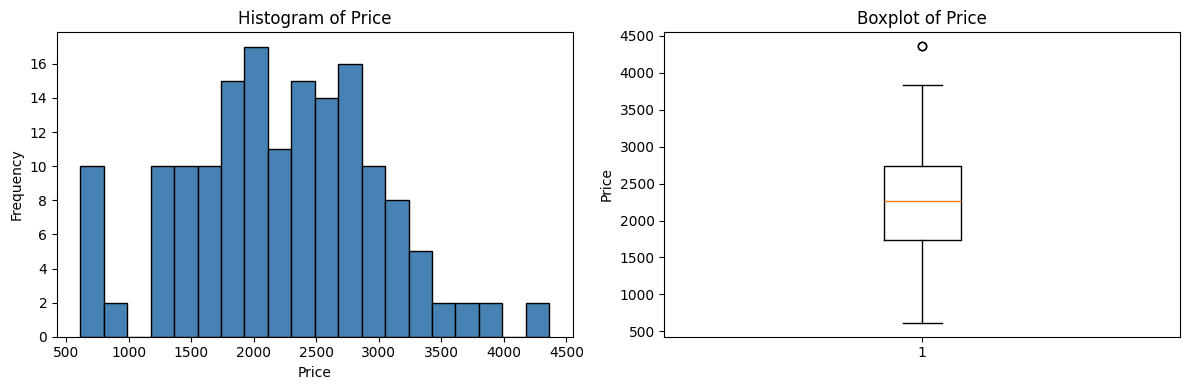

Skewness of Price: 0.0523


In [36]:
# pyright: ignore
# Import required libraries
import matplotlib.pyplot as plt
import pandas as pd 

# Distribution of target variable - Price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data["Price"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Histogram of Price")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].boxplot(data["Price"], vert=True)
axes[1].set_title("Boxplot of Price")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

print("Skewness of Price:", round(data["Price"].skew(), 4))

- Price distribution is nearly symmetric (skewness ~ 0.05)
- No major outliers visible
- Range is 614 to 4361 with mean around 2215
- Since target is already well distributed, no transformation needed for Price

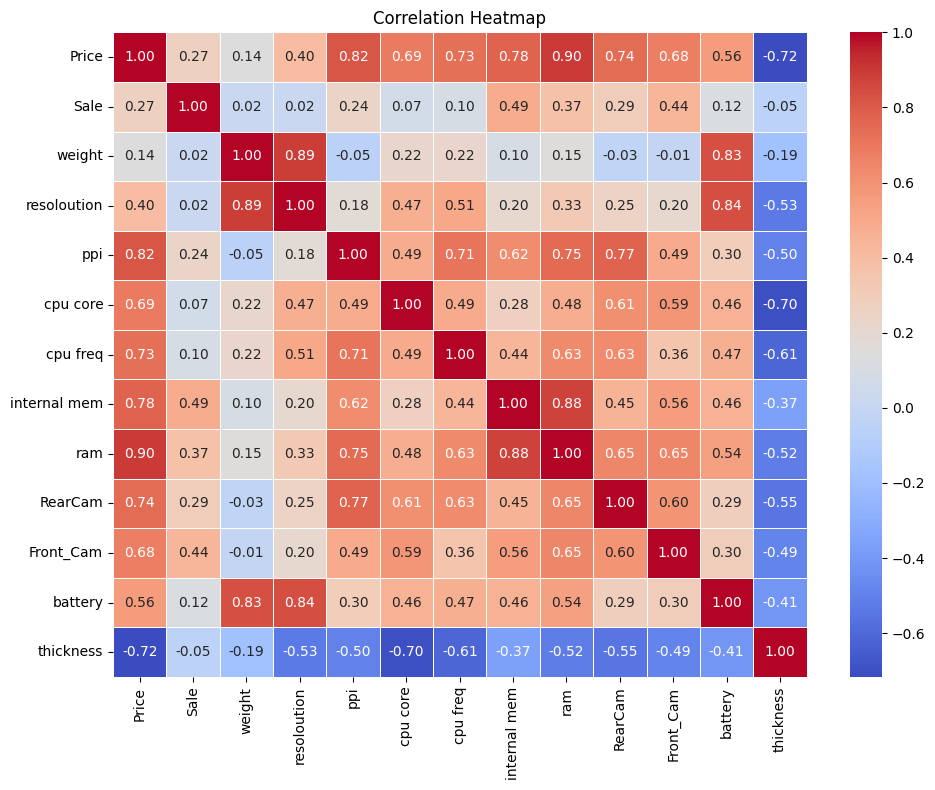

In [37]:
# pyright: ignore
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = data.corr()  # Make sure 'data' is defined/loaded before this line
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation observations
- Features like ram, resoloution, ppi, internal mem show good positive correlation with Price
- Sale has very low correlation with Price
- Some features are correlated with each other (multicollinearity) which we need to handle with regularization later

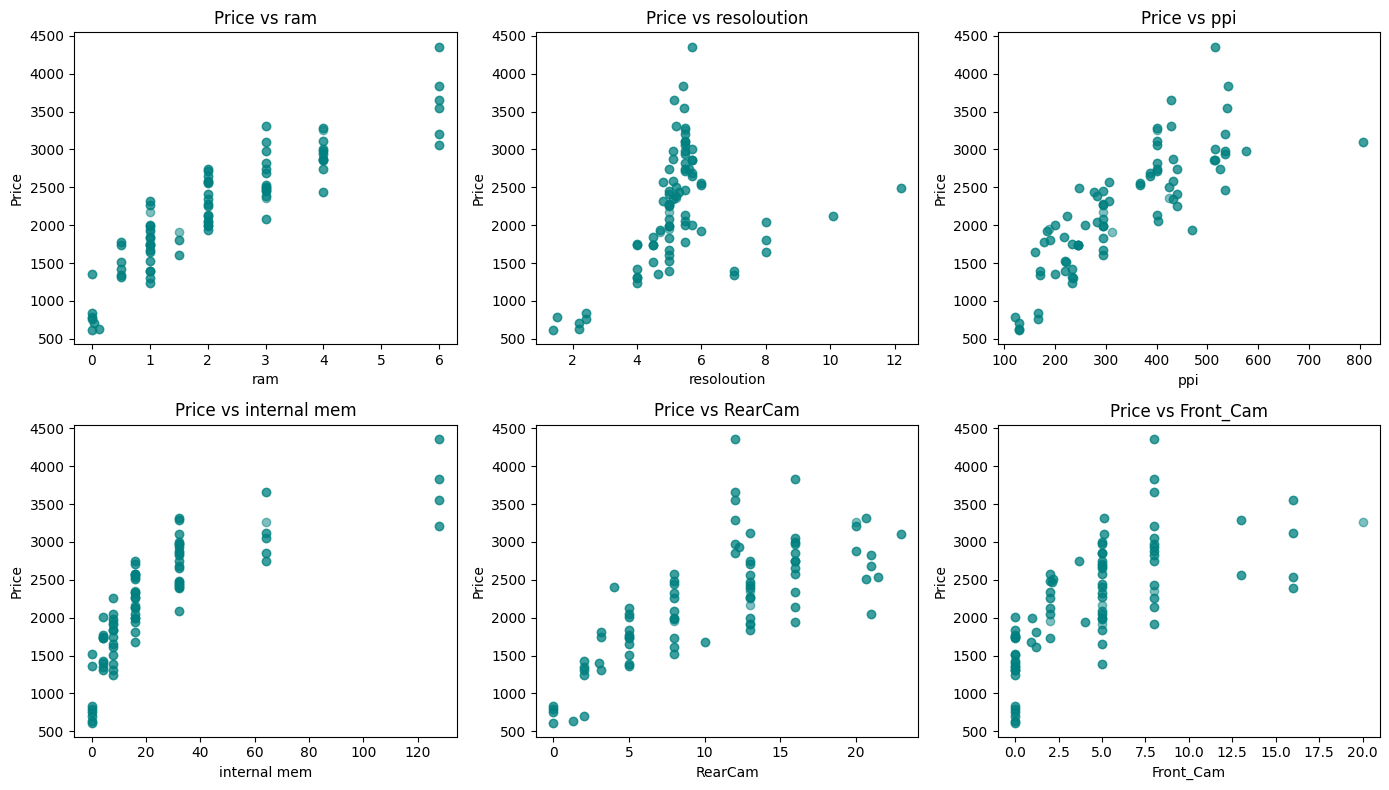

In [38]:
# pyright: ignore
# Scatter plots of top correlated features vs Price
top_features = ["ram", "resoloution", "ppi", "internal mem", "RearCam", "Front_Cam"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(top_features):
    row = i // 3
    col_idx = i % 3
    axes[row][col_idx].scatter(data[col], data["Price"], alpha=0.5, color="teal")
    axes[row][col_idx].set_xlabel(col)
    axes[row][col_idx].set_ylabel("Price")
    axes[row][col_idx].set_title("Price vs " + col)

plt.tight_layout()
plt.show()

## 3. Checking Distributions / Skewness and Transformations

In [39]:
# pyright: ignore
# Checking skewness of all features
skew_values = data.skew().sort_values(ascending=False)
print("Skewness of each column:")
print(skew_values)
print()

# identifying highly skewed columns
high_skew = skew_values[abs(skew_values) > 1]
print("Highly skewed columns:")
print(high_skew)

Skewness of each column:
Sale            4.269384
weight          3.981756
internal mem    2.389683
battery         2.092660
thickness       1.587680
resoloution     1.176110
Front_Cam       1.169750
ram             0.792698
ppi             0.602503
RearCam         0.106929
Price           0.052347
cpu core       -0.009077
cpu freq       -0.512663
dtype: float64

Highly skewed columns:
Sale            4.269384
weight          3.981756
internal mem    2.389683
battery         2.092660
thickness       1.587680
resoloution     1.176110
Front_Cam       1.169750
dtype: float64


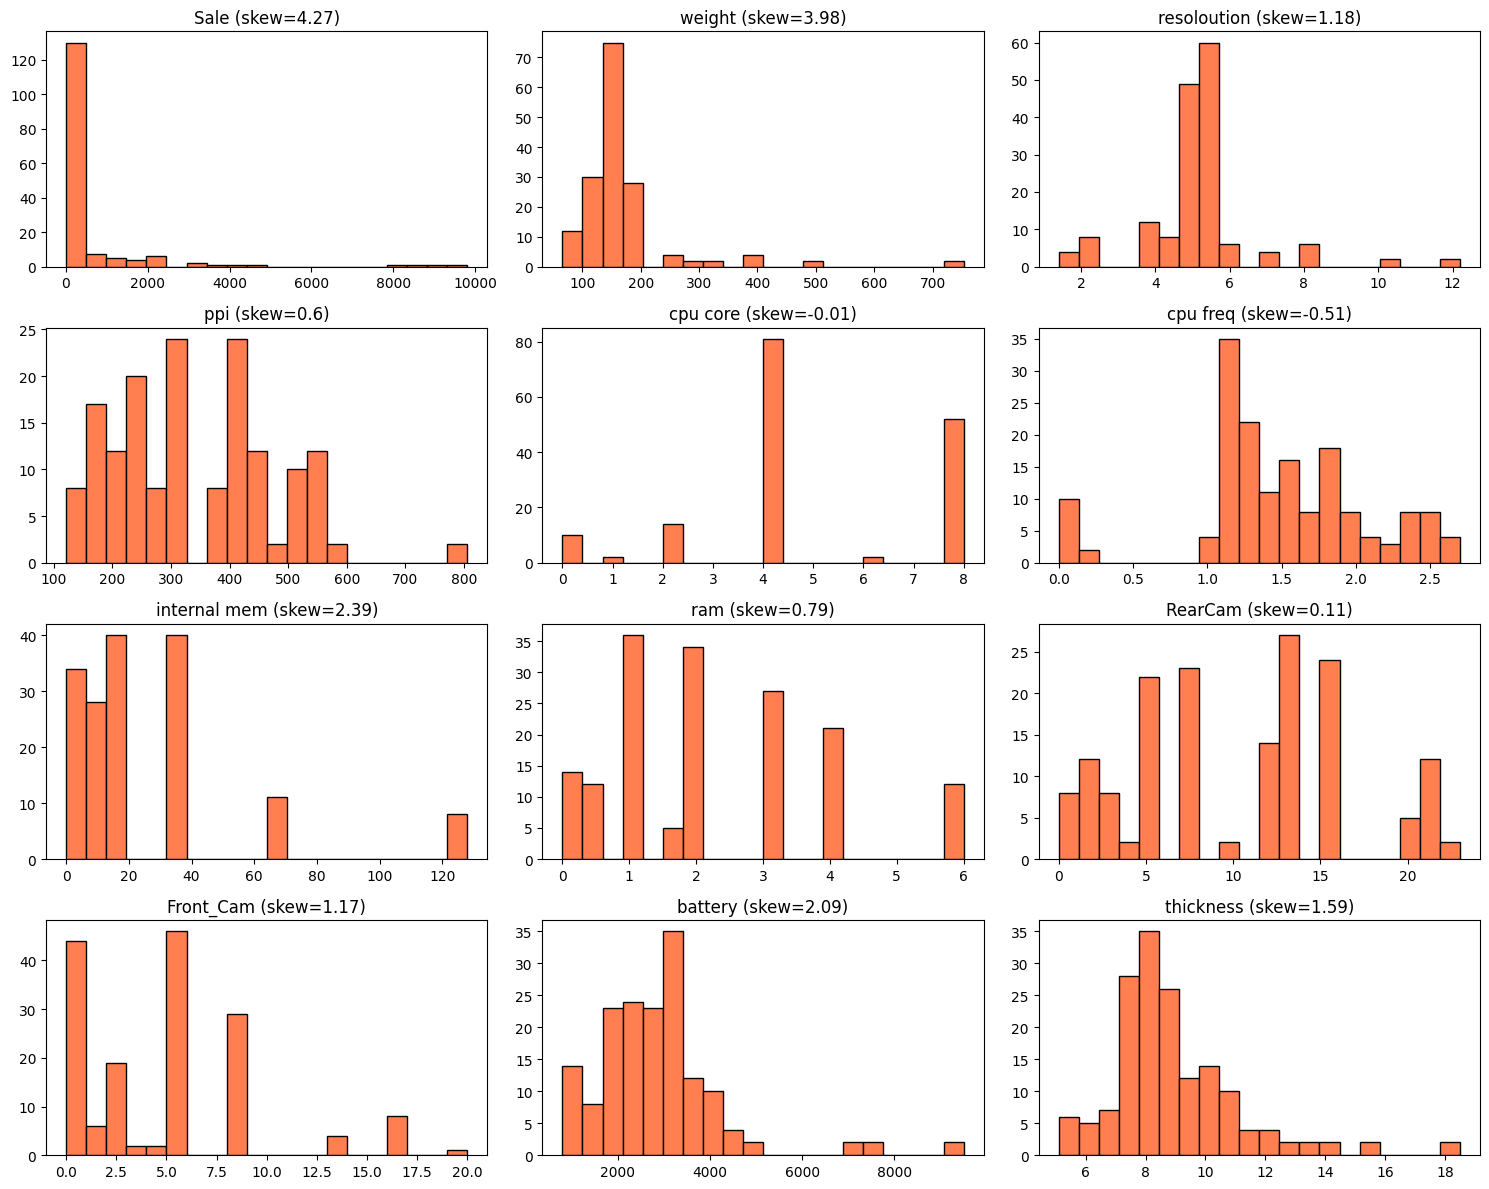

In [40]:
# pyright: ignore
# Distribution plots for all features
cols = data.columns.tolist()
cols.remove("Price")

n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

# Flatten axes array for simple indexing even when n_rows or n_cols equals 1
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, col in enumerate(cols):
    axes_flat[i].hist(data[col], bins=20, color="coral", edgecolor="black")
    skval = round(data[col].skew(), 2)
    axes_flat[i].set_title(col + " (skew=" + str(skval) + ")")

# Hide any unused subplots
for ax in axes_flat[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### 

Skewness observations
- Sale, weight, internal mem, battery, thickness, resoloution, Front_Cam are highly skewed
- For linear regression models, we will apply StandardScaler which handles this
- Log transformation can be applied for highly skewed features but since we are using regularized models with scaling, it is not strictly necessary here

## 4. Outlier Detection and Treatment + Feature Scaling

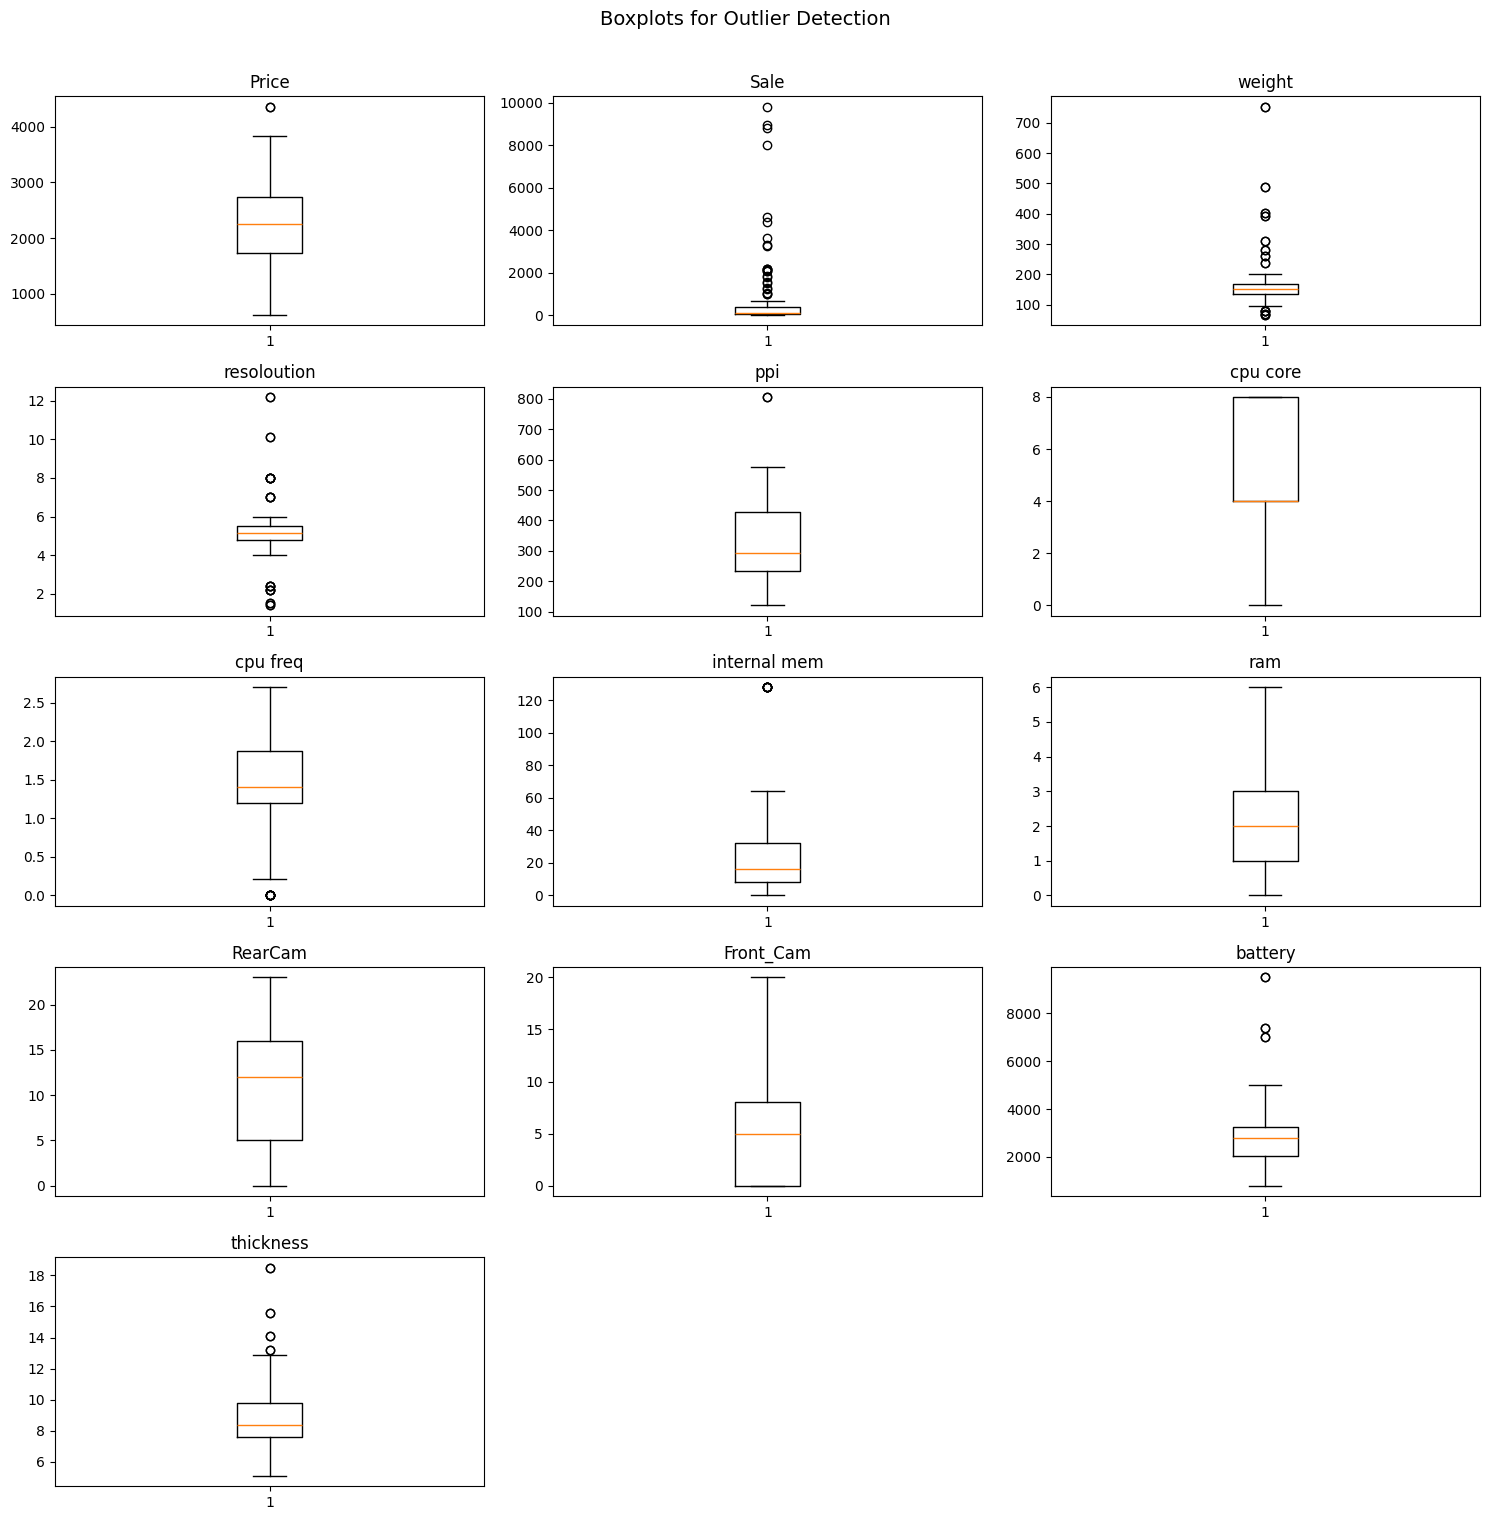

In [41]:
# pyright: ignore
# Boxplots to check outliers in all columns
all_cols = data.columns.tolist()
n_cols = 3
n_rows = (len(all_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

for i, col in enumerate(all_cols):
    r = i // n_cols
    c = i % n_cols
    axes[r][c].boxplot(data[col])
    axes[r][c].set_title(col)

# hide empty subplots
for j in range(len(all_cols), n_rows * n_cols):
    axes[j // n_cols][j % n_cols].set_visible(False)

plt.suptitle("Boxplots for Outlier Detection", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [42]:
# pyright: ignore
import numpy as np  # Import NumPy library to use np.nan

# Checking for suspicious zero values in technical specs
# A phone cannot have 0 cpu cores, 0 cpu freq, 0 ram, or 0 internal memory
suspect_cols = ["cpu core", "cpu freq", "internal mem", "ram"]

for col in suspect_cols:
    zero_count = (data[col] == 0).sum()
    print(col + ":", str(zero_count), "zero values")

print()
# replacing 0s with NaN so we can fill with median later
for col in suspect_cols:
    data[col] = data[col].replace(0, np.nan)  # Now np.nan is available

print("After replacing zeros with NaN:")
print(data.isnull().sum())

cpu core: 10 zero values
cpu freq: 10 zero values
internal mem: 10 zero values
ram: 2 zero values

After replacing zeros with NaN:
Price            0
Sale             0
weight           0
resoloution      0
ppi              0
cpu core        10
cpu freq        10
internal mem    10
ram              2
RearCam          0
Front_Cam        0
battery          0
thickness        0
dtype: int64


### Outlier and data quality observations
- Columns like Sale, weight, battery show outliers but these could be genuine values for different phone models
- Suspicious zero values were found in cpu core, cpu freq, internal mem, ram
- These zeros dont make sense technically, so we replaced them with NaN
- We will fill these NaN values with median after train-test split to avoid data leakage

## 5. Building ML Models to Predict Price

In [43]:
# pyright: ignore
# Import the required function from sklearn
from sklearn.model_selection import train_test_split

# Separating features and target
X = data.drop(columns=["Price"])
y = data["Price"]

# Train test split with 80-20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (128, 12)
Testing set: (33, 12)


In [44]:
# Filling NaN values with median from training data only
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing values after filling:")
print("Train:", X_train.isnull().sum().sum())
print("Test:", X_test.isnull().sum().sum())

Missing values after filling:
Train: 0
Test: 0


In [45]:
# Import StandardScaler from sklearn
from sklearn.preprocessing import StandardScaler
import pandas as pd  # Also importing pandas in case it's needed

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Scaled training data sample:")
X_train_sc.head()

Scaled training data sample:


,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
115,-0.220615,0.064071,0.351148,1.303784,-0.532421,0.724887,0.220797,1.118410,0.919051,0.070159,0.289210,-0.585008
2,-0.397968,-0.683076,-0.319202,-0.150404,-0.532421,-0.812844,-0.611229,-0.461349,0.443103,0.070159,-0.629752,-0.585008
123,-0.167232,0.306894,0.351148,-0.541081,-0.532421,-0.812844,-0.333887,-0.145397,-0.350144,-0.832388,0.442370,0.544944
45,-0.380173,-0.437918,-0.118097,-0.280630,-0.532421,-0.585032,-0.333887,-0.145397,0.443103,0.070159,-0.246851,-0.106952
42,-0.381360,-0.408733,-0.453272,-0.830472,-0.532421,-0.585032,-0.611229,-0.777300,-0.826093,-1.058025,-0.936072,0.501484


### Preprocessing done
- Missing values filled using training set medians only (to avoid data leakage)
- StandardScaler applied - this is important for Ridge, Lasso and ElasticNet as regularization is sensitive to feature scale

In [46]:
# pyright: ignore
# Function to train model and get metrics
def train_and_evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    
    result = {
        "Model": name,
        "Train MAE": round(mean_absolute_error(y_tr, train_pred), 2),
        "Test MAE": round(mean_absolute_error(y_te, test_pred), 2),
        "Train RMSE": round(np.sqrt(mean_squared_error(y_tr, train_pred)), 2),
        "Test RMSE": round(np.sqrt(mean_squared_error(y_te, test_pred)), 2),
        "Train R2": round(r2_score(y_tr, train_pred), 4),
        "Test R2": round(r2_score(y_te, test_pred), 4)
    }
    return result, model

### Model 1: Linear Regression

In [47]:
# pyright: ignore
# Import the LinearRegression class from sklearn
from sklearn.linear_model import LinearRegression
# Import necessary evaluation metrics that train_and_evaluate function likely uses
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd  # Also importing pandas since pd.DataFrame is used
import numpy as np  # Often needed for mathematical operations in ML

# Now the LinearRegression class and evaluation metrics are available for use
lr_result, lr_model = train_and_evaluate("Linear Regression", LinearRegression(), X_train_sc, X_test_sc, y_train, y_test)
pd.DataFrame([lr_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,147.7,136.1,181.36,166.74,0.9444,0.951


### Model 2: Ridge Regression (L2 Regularization)

In [48]:
# Import the Ridge class from scikit-learn
from sklearn.linear_model import Ridge
import pandas as pd

# Now the Ridge class is available to use
ridge_result, ridge_model = train_and_evaluate("Ridge Regression", Ridge(alpha=1.0), X_train_sc, X_test_sc, y_train, y_test)
pd.DataFrame([ridge_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Ridge Regression,147.35,134.67,181.45,166.91,0.9443,0.9509


### Model 3: Lasso Regression (L1 Regularization)

In [49]:
# Import necessary libraries
from sklearn.linear_model import Lasso
import pandas as pd

# Now the Lasso class is available to use
lasso_result, lasso_model = train_and_evaluate("Lasso Regression", Lasso(alpha=1.0), X_train_sc, X_test_sc, y_train, y_test)
pd.DataFrame([lasso_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Lasso Regression,147.21,135.0,181.5,166.65,0.9443,0.951


### Model 4: ElasticNet Regression (L1 + L2)

In [50]:
# Import ElasticNet from scikit-learn
from sklearn.linear_model import ElasticNet
import pandas as pd

# Now ElasticNet is defined and can be used
enet_result, enet_model = train_and_evaluate("ElasticNet", ElasticNet(alpha=1.0, l1_ratio=0.5), X_train_sc, X_test_sc, y_train, y_test)
pd.DataFrame([enet_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,ElasticNet,168.37,165.57,211.53,219.26,0.9243,0.9152


## 6. Overfitting Check and Model Comparison

In [51]:
# Comparison table of all models
comparison_df = pd.DataFrame([lr_result, ridge_result, lasso_result, enet_result])
comparison_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,147.70,136.10,181.36,166.74,0.9444,0.9510
1,Ridge Regression,147.35,134.67,181.45,166.91,0.9443,0.9509
2,Lasso Regression,147.21,135.00,181.50,166.65,0.9443,0.9510
3,ElasticNet,168.37,165.57,211.53,219.26,0.9243,0.9152


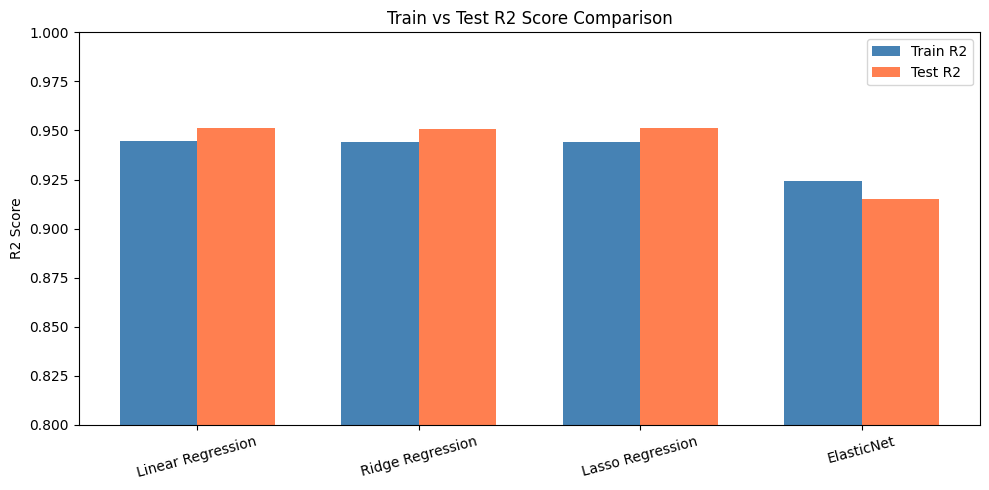

In [52]:
# pyright: ignore
# Visual comparison of R2 scores
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(comparison_df))
width = 0.35

ax.bar(x_pos - width/2, comparison_df["Train R2"], width, label="Train R2", color="steelblue")
ax.bar(x_pos + width/2, comparison_df["Test R2"], width, label="Test R2", color="coral")

ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df["Model"], rotation=15)
ax.set_ylabel("R2 Score")
ax.set_title("Train vs Test R2 Score Comparison")
ax.legend()
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

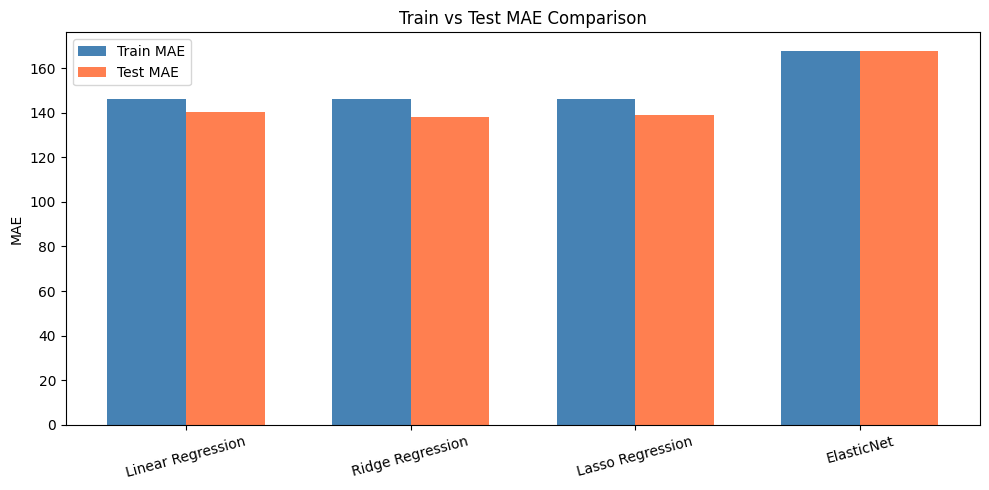

In [28]:
# pyright: ignore
# Comparison of MAE values
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x_pos - width/2, comparison_df["Train MAE"], width, label="Train MAE", color="steelblue")
ax.bar(x_pos + width/2, comparison_df["Test MAE"], width, label="Test MAE", color="coral")

ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df["Model"], rotation=15)
ax.set_ylabel("MAE")
ax.set_title("Train vs Test MAE Comparison")
ax.legend()
plt.tight_layout()
plt.show()

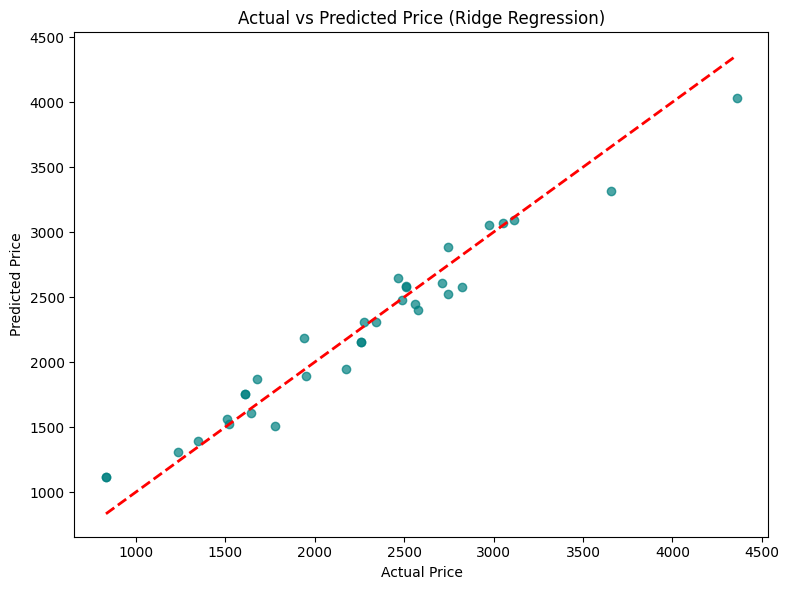

In [53]:
# pyright: ignore
# Actual vs Predicted plot for best model (Ridge)
best_pred = ridge_model.predict(X_test_sc)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, color="teal", alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Ridge Regression)")
plt.tight_layout()
plt.show()

## Conclusion

- All four models (Linear, Ridge, Lasso, ElasticNet) were trained and evaluated
- Train and Test R2 scores are very close for Linear, Ridge and Lasso which shows **no overfitting**
- ElasticNet with default alpha=1.0 performs slightly weaker, meaning it may be over-regularizing
- **Ridge Regression** gives the best balance of performance with lowest Test MAE
- Since there is no significant overfitting in basic Linear Regression itself, regularization mainly helps with multicollinearity here
- The model can predict mobile phone prices with reasonable accuracy based on given specifications

In [54]:
import joblib
# Save the best-trained model and the scaler
joblib.dump(ridge_model, "mobile_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']